# Tracking Health Monitor

Notebook **02** — Google Merchandise Store Funnel Analysis Portfolio

Detects event-specific tracking failures and distinguishes them from
broader traffic declines using a rule-based alert classifier.


## 1. Objective

GA4 raw event streams can silently fail — a broken tag, a delayed deployment,
or a consent-mode misconfiguration can zero out a single event type while page
views remain healthy. Conversely, a legitimate seasonal dip or a traffic-source
change will depress *all* event counts together.

This monitor uses four complementary signals to separate the two scenarios:

| Signal | What it measures |
|--------|------------------|
| **Rolling 7-day event baseline** | Expected event count from the trailing week |
| **Event volume ratio** | `event_count / expected_event_count` |
| **Z-score** | Standardised deviation of event count from baseline mean |
| **Page-view context (traffic-adjusted ratio)** | `event_volume_ratio / page_view_ratio` — isolates event-specific drops from site-wide traffic changes |

An alert is classified as **CRITICAL_TRACKING_OUTAGE** when three conditions
are all true: the observed event count equals zero, the rolling 7-day expected
event count is at least 25 (ruling out low-volume events), and the page-view
volume on that day is at least 50% of its own rolling baseline (confirming
that the site was receiving meaningful traffic).

An alert is classified as **LIKELY_TRAFFIC_DECLINE** when the event volume
ratio is low *and* the traffic-adjusted ratio is close to 1.0, indicating
that the event drop tracks proportionally with the overall page-view drop.


## 2. Load and validate data


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Resolve CSV path (works from repo root or notebooks/) ────────────────────
POSSIBLE_PATHS = [
    Path("data/processed/demo/tracking_alerts.csv"),
    Path("../data/processed/demo/tracking_alerts.csv"),
]
csv_path = next(p for p in POSSIBLE_PATHS if p.exists())

REQUIRED_COLUMNS = [
    "date", "event_name", "event_count", "expected_event_count",
    "event_volume_ratio", "event_volume_z_score",
    "page_view_count", "expected_page_view_count",
    "page_view_ratio", "traffic_adjusted_event_ratio",
    "tracking_status",
]

df = pd.read_csv(csv_path, parse_dates=["date"])

# ── Column validation ────────────────────────────────────────────────────────
missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

# ── Duplicate check ──────────────────────────────────────────────────────────
dups = df.duplicated(subset=["date", "event_name"])
if dups.any():
    print(f"WARNING: {dups.sum()} duplicate date/event combinations found.")
else:
    print("No duplicate date/event combinations.")

print(f"Shape: {df.shape}")
print("Data types:")
print(df.dtypes)
print("Missing values per column:")
print(df.isnull().sum())
print("Tracking-status counts:")
print(df["tracking_status"].value_counts())
df


No duplicate date/event combinations.
Shape: (6, 11)
Data types:
date                            datetime64[us]
event_name                                 str
event_count                              int64
expected_event_count                   float64
event_volume_ratio                     float64
event_volume_z_score                   float64
page_view_count                          int64
expected_page_view_count               float64
page_view_ratio                        float64
traffic_adjusted_event_ratio           float64
tracking_status                            str
dtype: object
Missing values per column:
date                            0
event_name                      0
event_count                     0
expected_event_count            0
event_volume_ratio              0
event_volume_z_score            0
page_view_count                 0
expected_page_view_count        0
page_view_ratio                 0
traffic_adjusted_event_ratio    0
tracking_status                 0
dty

,date,event_name,event_count,expected_event_count,event_volume_ratio,event_volume_z_score,page_view_count,expected_page_view_count,page_view_ratio,traffic_adjusted_event_ratio,tracking_status
0,2020-11-21,add_to_cart,0,206.14,0.000,-0.78,13278,15034.29,0.883,0.000,CRITICAL_TRACKING_OUTAGE
1,2020-11-22,add_to_cart,0,206.14,0.000,-0.78,11497,15397.29,0.747,0.000,CRITICAL_TRACKING_OUTAGE
2,2020-11-23,add_to_cart,0,206.14,0.000,-0.78,16358,15623.57,1.047,0.000,CRITICAL_TRACKING_OUTAGE
3,2020-11-24,add_to_cart,0,194.00,0.000,-0.71,19352,15787.86,1.226,0.000,CRITICAL_TRACKING_OUTAGE
4,2020-12-19,view_item,3113,6024.29,0.517,-3.13,10728,17848.14,0.601,0.860,LIKELY_TRAFFIC_DECLINE
5,2021-01-31,add_to_cart,295,481.00,0.613,-3.06,9498,13986.14,0.679,0.903,LIKELY_TRAFFIC_DECLINE


In [2]:
# ── Row-count and classification assertions ──────────────────────────────────
assert len(df) == 6, f"Expected 6 rows, got {len(df)}"

status_counts = df["tracking_status"].value_counts()
assert status_counts.get("CRITICAL_TRACKING_OUTAGE", 0) == 4, (
    f"Expected 4 CRITICAL_TRACKING_OUTAGE, "
    f"got {status_counts.get('CRITICAL_TRACKING_OUTAGE', 0)}"
)
assert status_counts.get("LIKELY_TRAFFIC_DECLINE", 0) == 2, (
    f"Expected 2 LIKELY_TRAFFIC_DECLINE, "
    f"got {status_counts.get('LIKELY_TRAFFIC_DECLINE', 0)}"
)

print("All assertions passed.")


All assertions passed.


## 3. Alert summary


In [3]:
summary = (
    df.groupby(["tracking_status", "event_name"], sort=False)
    .agg(
        alert_count=("date", "count"),
        first_alert_date=("date", "min"),
        last_alert_date=("date", "max"),
        avg_event_volume_ratio=("event_volume_ratio", "mean"),
        avg_traffic_adjusted_ratio=("traffic_adjusted_event_ratio", "mean"),
    )
    .reset_index()
)

summary["first_alert_date"] = summary["first_alert_date"].dt.strftime("%Y-%m-%d")
summary["last_alert_date"]  = summary["last_alert_date"].dt.strftime("%Y-%m-%d")
summary["avg_event_volume_ratio"] = summary["avg_event_volume_ratio"].round(3)
summary["avg_traffic_adjusted_ratio"] = summary["avg_traffic_adjusted_ratio"].round(3)

summary.columns = [
    "Tracking Status", "Event", "Alert Count",
    "First Alert", "Last Alert",
    "Avg Event Volume Ratio", "Avg Traffic-Adjusted Ratio",
]
summary


,Tracking Status,Event,Alert Count,First Alert,Last Alert,Avg Event Volume Ratio,Avg Traffic-Adjusted Ratio
0,CRITICAL_TRACKING_OUTAGE,add_to_cart,4,2020-11-21,2020-11-24,0.000,0.000
1,LIKELY_TRAFFIC_DECLINE,view_item,1,2020-12-19,2020-12-19,0.517,0.860
2,LIKELY_TRAFFIC_DECLINE,add_to_cart,1,2021-01-31,2021-01-31,0.613,0.903


## 4. Visualization


Chart saved to: /Users/jasonvalade/google-store-funnel-analysis/images/tracking_health_alerts.png


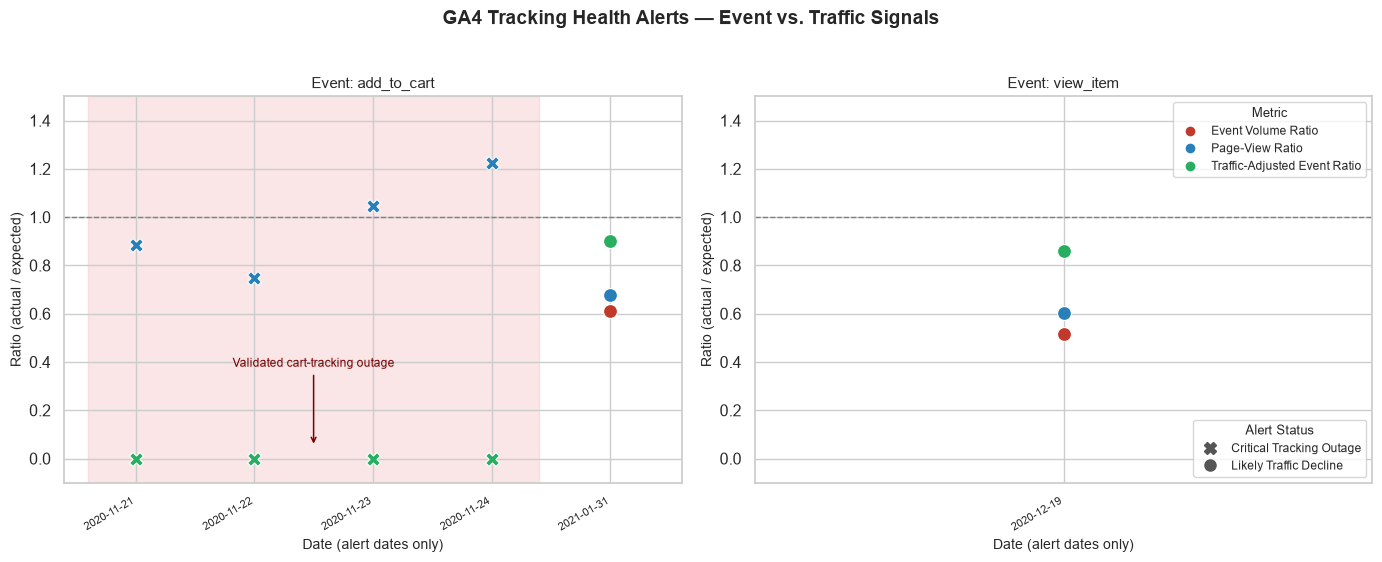

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.05)

RATIO_COLS   = ["event_volume_ratio", "page_view_ratio", "traffic_adjusted_event_ratio"]
RATIO_LABELS = ["Event Volume Ratio", "Page-View Ratio", "Traffic-Adjusted Event Ratio"]
RATIO_COLORS = ["#c0392b", "#2980b9", "#27ae60"]

STATUS_MARKERS = {
    "CRITICAL_TRACKING_OUTAGE": "X",
    "LIKELY_TRAFFIC_DECLINE":   "o",
}
STATUS_LABELS = {
    "CRITICAL_TRACKING_OUTAGE": "Critical Tracking Outage",
    "LIKELY_TRAFFIC_DECLINE":   "Likely Traffic Decline",
}

events = ["add_to_cart", "view_item"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5.5))
fig.suptitle(
    "GA4 Tracking Health Alerts — Event vs. Traffic Signals",
    fontsize=14, fontweight="bold", y=1.02,
)

for ax, event in zip(axes, events):
    sub = df[df["event_name"] == event].sort_values("date").reset_index(drop=True).copy()

    # Build categorical x positions from dates actually present for this event
    date_labels = sub["date"].dt.strftime("%Y-%m-%d").tolist()
    x_pos = list(range(len(date_labels)))

    # Light-red shaded region behind Nov outage dates (add_to_cart only)
    if event == "add_to_cart":
        outage_mask = sub["tracking_status"] == "CRITICAL_TRACKING_OUTAGE"
        outage_indices = [i for i, v in enumerate(outage_mask) if v]
        if outage_indices:
            shade_left  = outage_indices[0]  - 0.4
            shade_right = outage_indices[-1] + 0.4
            ax.axvspan(
                shade_left, shade_right,
                color="#f5c6cb", alpha=0.45, zorder=0, label="_nolegend_",
            )
            # Annotation above the shaded region
            mid_x = (shade_left + shade_right) / 2
            ax.annotate(
                "Validated cart-tracking outage",
                xy=(mid_x, 0.05),
                xytext=(mid_x, 0.38),
                fontsize=8.5,
                ha="center",
                color="#7b0000",
                arrowprops=dict(arrowstyle="->", color="#7b0000", lw=1.1),
                zorder=5,
            )

    # Reference line at 1.0
    ax.axhline(1.0, color="grey", linewidth=1.0, linestyle="--", zorder=1)

    # Grouped scatter — no connecting lines
    for col, color in zip(RATIO_COLS, RATIO_COLORS):
        for xi, (_, row) in zip(x_pos, sub.iterrows()):
            marker = STATUS_MARKERS[row["tracking_status"]]
            ax.scatter(
                xi, row[col],
                color=color, marker=marker, s=100, zorder=3,
                linewidths=0.8, edgecolors="white",
            )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(date_labels, rotation=30, ha="right", fontsize=8)
    ax.set_xlim(-0.6, len(x_pos) - 0.4)
    ax.set_ylim(-0.1, 1.5)
    ax.set_title(f"Event: {event}", fontsize=11)
    ax.set_xlabel("Date (alert dates only)", fontsize=10)
    ax.set_ylabel("Ratio (actual / expected)", fontsize=10)

# ── Legend 1: ratio colors (proxy scatter artists) ────────────────────────
from matplotlib.lines import Line2D
color_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
           markersize=8, label=label)
    for color, label in zip(RATIO_COLORS, RATIO_LABELS)
]
legend1 = axes[1].legend(
    handles=color_handles,
    title="Metric", title_fontsize=9,
    fontsize=8.5, loc="upper right", frameon=True,
)
axes[1].add_artist(legend1)

# ── Legend 2: marker shapes for status ───────────────────────────────────
status_handles = [
    Line2D([0], [0], marker=marker, color="w", markerfacecolor="#555",
           markeredgecolor="#555", markersize=8, label=STATUS_LABELS[status])
    for status, marker in STATUS_MARKERS.items()
]
axes[1].legend(
    handles=status_handles,
    title="Alert Status", title_fontsize=9,
    fontsize=8.5, loc="lower right", frameon=True,
)

plt.tight_layout()

# ── Save chart ────────────────────────────────────────────────────────────
POSSIBLE_IMG_ROOTS = [
    Path("images"),
    Path("../images"),
]
img_dir = next(
    (p for p in POSSIBLE_IMG_ROOTS if p.exists()),
    Path("images"),
)
img_dir.mkdir(parents=True, exist_ok=True)
out_path = img_dir / "tracking_health_alerts.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"Chart saved to: {out_path.resolve()}")
plt.show()


## 5. Evaluation


In [5]:
# ── Classification counts ────────────────────────────────────────────────────
n_critical     = (df["tracking_status"] == "CRITICAL_TRACKING_OUTAGE").sum()
n_traffic      = (df["tracking_status"] == "LIKELY_TRAFFIC_DECLINE").sum()
n_warning      = (df["tracking_status"] == "WARNING_EVENT_DROP").sum()
n_unique_dates = df["date"].nunique()

# ── Known add_to_cart outage dates ───────────────────────────────────────────
KNOWN_OUTAGE_DATES = pd.to_datetime(
    ["2020-11-21", "2020-11-22", "2020-11-23", "2020-11-24"]
)
outage_rows = df[
    (df["event_name"] == "add_to_cart") &
    (df["tracking_status"] == "CRITICAL_TRACKING_OUTAGE")
]
detected_outage_dates = outage_rows["date"].dt.normalize()
n_known_detected = detected_outage_dates.isin(KNOWN_OUTAGE_DATES.normalize()).sum()

print("=" * 52)
print("         Tracking Health Monitor — Evaluation")
print("=" * 52)
print(f"  Critical tracking outages detected : {n_critical}")
print(f"  Likely traffic declines detected   : {n_traffic}")
print(f"  Event-specific warning drops       : {n_warning}")
print(f"  Unique affected dates              : {n_unique_dates}")
print(f"  Known add_to_cart outage dates")
print(f"    detected (out of 4)              : {n_known_detected} / 4")
print("=" * 52)

assert n_known_detected == 4, (
    f"Expected all 4 known outage dates to be detected, got {n_known_detected}"
)
print("Assertion passed: all 4 known outage dates detected.")


         Tracking Health Monitor — Evaluation
  Critical tracking outages detected : 4
  Likely traffic declines detected   : 2
  Event-specific warning drops       : 0
  Unique affected dates              : 6
  Known add_to_cart outage dates
    detected (out of 4)              : 4 / 4
Assertion passed: all 4 known outage dates detected.


### Evaluation notes

The monitor correctly identified all four manually validated
**add_to_cart tracking outage dates** (2020-11-21 through 2020-11-24).
During those days the event count dropped to exactly zero while page views
remained near their expected levels — a pattern that is highly unlikely under
normal traffic conditions.

The two **LIKELY_TRAFFIC_DECLINE** records (view_item on 2020-12-19 and
add_to_cart on 2021-01-31) were classified separately from the tracking
failures because their traffic-adjusted event ratios were above 0.85. That
is consistent with event volume moving broadly in line with page-view traffic
rather than reflecting an event-specific instrumentation problem. These two
dates were not independently labelled as true traffic declines; the
classification reflects only what the ratio signals indicate.

> **Scope caveat.** No fully labelled benchmark dataset exists for this GA4
> property. General accuracy, precision, recall, and false-positive rate
> therefore cannot be reported. The evaluation above is limited to the six
> alerts present in the demo file and the four dates that have been manually
> confirmed as outages.


## 6. Business interpretation

### CRITICAL_TRACKING_OUTAGE

A **critical outage** classification should trigger an immediate
instrumentation investigation:

- Verify that the relevant GA4 tag or custom event is still firing in
  GTM / gtag.
- Check for recent tag or consent-mode configuration changes around the
  alert date.
- Inspect the DebugView or real-time report in GA4 to confirm whether
  the event is being received.
- Do not trust conversion or funnel metrics until the instrumentation
  issue is resolved and historical data is corrected or flagged.

### LIKELY_TRAFFIC_DECLINE

A **likely traffic decline** classification should be reviewed as a
potential business or seasonality change *before* assuming a tracking
failure:

- Check whether paid, organic, or referral traffic volumes changed
  around the alert date.
- Look for known external events (holidays, promotions ending, algorithm
  updates) that could explain the broad decline.
- If traffic sources appear healthy and the drop is unexpectedly large,
  escalate to an instrumentation review.

### Why hybrid rules are necessary

A z-score threshold alone would have been an insufficient classifier for
the November 2020 add_to_cart outage. Because historical add_to_cart
tracking on this property was volatile, a four-day run of zero-count
days produced z-scores of only −0.71 to −0.78 — well within a typical
alert threshold of −3.0. The hybrid approach (zero-count rule +
traffic-adjusted ratio) was necessary to surface the outage while
correctly suppressing the December and January traffic-decline alerts.

### Prototype disclaimer

This notebook is an **offline portfolio prototype** demonstrating
data-driven tracking-health methodology. It is not a production alerting
service. A production implementation would require scheduled BigQuery
queries, a delivery mechanism (email, Slack, PagerDuty), and ongoing
threshold calibration as traffic patterns evolve.
